In [1]:
from pathlib import Path
import os, sys
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

LAB10_DIR = PROJECT_ROOT / "data" / "processed" / "analytics" / "lab10"
LAB10_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_CSV = PROJECT_ROOT / "data" / "processed" / "cleaned" / "cleaned_data.csv"

print("Project root:", PROJECT_ROOT)
print("Cleaned CSV exists:", CLEANED_CSV.exists())
print("Lab 10 output directory:", LAB10_DIR)

Project root: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD
Cleaned CSV exists: True
Lab 10 output directory: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10


In [2]:
from src.analytics.db_connector import setup_mysql_from_cleaned_data, prepare_article_metrics
from src.analytics.data_combiner import (
    prepare_metadata_df, merge_metadata_with_metrics, compare_join_types,
    save_join_count_chart, save_combined_outputs,
)
from src.analytics.pivot_builder import (
    add_primary_category, add_analysis_year, wide_to_long_metrics, long_to_wide_metrics,
    build_category_year_pivot, build_document_category_pivot,
    build_language_decade_crosstab, save_pivot_outputs,
)
from src.analytics.aggregator import (
    category_summary, document_type_summary, yearly_trends, top_n_per_group,
    add_group_average_columns, filter_large_categories,
    save_yearly_trends_chart, save_aggregation_outputs,
)
from src.analytics.time_series import (
    parse_news_dates, add_date_components, build_monthly_time_series,
    resample_yearly, resample_quarterly, add_rolling_averages,
    save_time_series_chart, save_time_series_outputs,
)
from src.analytics.mongo_pipeline import (
    run_category_aggregation, run_document_type_aggregation, run_source_aggregation,
    save_mongo_aggregation_outputs,
)
from src.analytics.insight_reporter import generate_insight_questions, save_insight_outputs
from src.pipeline.run_pipeline import run_lab10_analysis_stage

print("All Lab 10 imports loaded.")

c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All Lab 10 imports loaded.


## 1. Load Lab 9 Cleaned Data

In [3]:
if not CLEANED_CSV.exists():
    raise FileNotFoundError("Run Lab 9 first. Missing: " + str(CLEANED_CSV))

cleaned_df = pd.read_csv(CLEANED_CSV)
print("Cleaned dataset shape:", cleaned_df.shape)
display(cleaned_df.head())
display(pd.DataFrame({"column": cleaned_df.columns, "dtype": cleaned_df.dtypes.astype(str)}).head(25))

Cleaned dataset shape: (1318, 35)


,record_id,source_name,title,description,url,source_path,fetched_at,version,document_type,file_name,...,published_year,content_length,title_length,rating_score,overview,genres,popularity,original_language,vote_average,vote_count
0,52,bbc,Election Update,No content available.,NaN,NaN,NaN,NaN,excel,news_data.xlsx,...,2026.0,15,15,4.0,Election Update,politics,34.0,unknown,4.0,34.0
1,53,reuters,AI Market Growth,No content available.,NaN,NaN,NaN,NaN,excel,news_data.xlsx,...,2026.0,16,16,7.0,AI Market Growth,business,28.0,unknown,7.0,28.0
2,54,cnn,Sports Highlights,No content available.,NaN,NaN,NaN,NaN,excel,news_data.xlsx,...,2026.0,17,17,5.0,Sports Highlights,sports,19.0,unknown,5.0,19.0
3,55,ap,Climate Policy Shift,No content available.,NaN,NaN,NaN,NaN,excel,news_data.xlsx,...,2026.0,20,20,3.0,Climate Policy Shift,politics,23.0,unknown,3.0,23.0
4,56,le monde,Café Culture Trends,No content available.,NaN,NaN,NaN,NaN,excel,news_data.xlsx,...,2026.0,19,19,6.0,Café Culture Trends,culture,14.0,unknown,6.0,14.0


,column,dtype
record_id,record_id,int64
source_name,source_name,str
title,title,str
description,description,str
url,url,str
source_path,source_path,str
fetched_at,fetched_at,str
version,version,float64
document_type,document_type,str
file_name,file_name,str


## 2. MySQL Database, Table, Insert, and Query

In [4]:
prepared_metrics_df = prepare_article_metrics(cleaned_df)
print("Prepared metrics shape:", prepared_metrics_df.shape)
display(prepared_metrics_df.head(10))

mysql_metrics_df = setup_mysql_from_cleaned_data(cleaned_csv_path=str(CLEANED_CSV))
print("MySQL queried metrics shape:", mysql_metrics_df.shape)
display(mysql_metrics_df.head(10))

mysql_metrics_df.to_csv(LAB10_DIR / "mysql_news_article_metrics.csv", index=False)

Prepared metrics shape: (1318, 13)


,record_id,title,primary_category,document_type,source_name,published_date,published_year,rating_score,popularity,content_length,title_length,engagement_score,estimated_value
0,52,Election Update,politics,excel,bbc,2026-03-20,2026.0,4.0,34.0,15,15,41.85,669.60
1,53,AI Market Growth,business,excel,reuters,2026-03-21,2026.0,7.0,28.0,16,16,71.56,1216.52
2,54,Sports Highlights,sports,excel,cnn,2026-03-21,2026.0,5.0,19.0,17,17,51.12,920.16
3,55,Climate Policy Shift,politics,excel,ap,2026-03-22,2026.0,3.0,23.0,20,20,31.35,658.35
4,56,Café Culture Trends,culture,excel,le monde,2026-03-22,2026.0,6.0,14.0,19,19,60.89,1217.80
5,57,München Startup Round,technology,excel,dw,2026-03-23,2026.0,8.0,17.0,21,21,81.06,1783.32
6,58,Žurnal Election Pulse,politics,excel,žurnal,2026-03-23,2026.0,5.0,21.0,21,21,51.26,1127.72
7,59,Streaming Rights Watch,business,excel,financial times,2026-03-24,2026.0,4.0,26.0,22,22,41.52,954.96
8,60,Weekend Match Buzz,sports,excel,espn,2026-03-24,2026.0,7.0,31.0,18,18,71.73,1362.87
9,61,Inflation Briefing,business,excel,al jazeera,2026-03-25,2026.0,2.0,22.0,18,18,21.28,404.32


MySQL queried metrics shape: (1318, 13)


c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\src\analytics\db_connector.py:419: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connection, params=params)


,record_id,title,primary_category,document_type,source_name,published_date,published_year,rating_score,popularity,content_length,title_length,engagement_score,estimated_value
0,48,Untitled record,pdf_two_column,pdf_two_column,data/raw/pdf/news_two_column.pdf,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
1,80,Untitled record,pdf_two_column,pdf_two_column,data/raw/pdf/news_two_column.pdf,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
2,112,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
3,152,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
4,193,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
5,449,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
6,705,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
7,961,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
8,1217,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,15,227.44,483310.0
9,51,Untitled record,word_two_column,word_two_column,data/raw/word/news_two_column.docx,NaT,NaN,10.0,1877.0,1877,15,212.62,399300.0


## 3. Combine MySQL Metrics with Cleaned/Mongo-Style Metadata

  inner  join ->  1318 rows
  left   join ->  1318 rows
  right  join ->  1318 rows
  outer  join ->  1318 rows
Metadata shape: (1318, 13)
Combined shape: (1318, 25)


,join_type,row_count
0,inner,1318
1,left,1318
2,right,1318
3,outer,1318


,record_id,title_mysql,primary_category,document_type_mysql,source_name_mysql,published_date_mysql,published_year_mysql,rating_score,popularity,content_length,...,url,source_path,file_name,category,document_type_mongo,source_name_mongo,language,content_text,published_date_mongo,published_year_mongo
0,48,Untitled record,pdf_two_column,pdf_two_column,data/raw/pdf/news_two_column.pdf,NaT,NaN,10.0,2124.0,2124,...,NaN,NaN,news_two_column.pdf,pdf_two_column,pdf_two_column,data/raw/pdf/news_two_column.pdf,unknown,News Monit Two Colu Two-column layout for extr...,NaN,NaN
1,80,Untitled record,pdf_two_column,pdf_two_column,data/raw/pdf/news_two_column.pdf,NaT,NaN,10.0,2124.0,2124,...,NaN,NaN,news_two_column.pdf,pdf_two_column,pdf_two_column,data/raw/pdf/news_two_column.pdf,unknown,News Monit Two Colu Two-column layout for extr...,NaN,NaN
2,112,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,...,NaN,data/raw/pdf/news_two_column.pdf,news_two_column.pdf,pdf_two_column,pdf_two_column,unknown,unknown,News Monit Two Colu Two-column layout for extr...,NaN,NaN
3,152,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,...,NaN,data/raw/pdf/news_two_column.pdf,news_two_column.pdf,pdf_two_column,pdf_two_column,unknown,unknown,News Monit Two Colu Two-column layout for extr...,NaN,NaN
4,193,Untitled record,pdf_two_column,pdf_two_column,unknown,NaT,NaN,10.0,2124.0,2124,...,NaN,data/raw/pdf/news_two_column.pdf,news_two_column.pdf,pdf_two_column,pdf_two_column,unknown,unknown,News Monit Two Colu Two-column layout for extr...,NaN,NaN


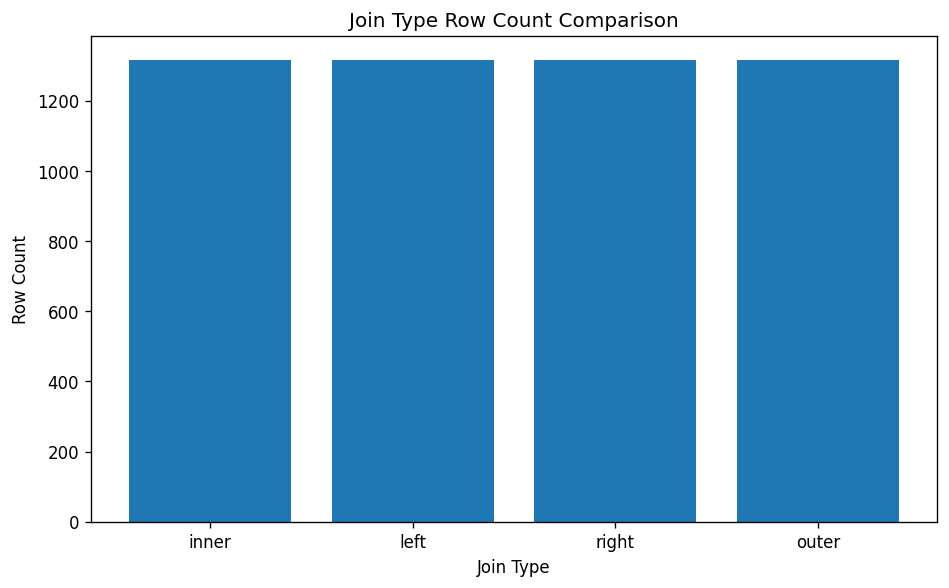

In [5]:
metadata_df = prepare_metadata_df(cleaned_df)
combined_df = merge_metadata_with_metrics(metadata_df, mysql_metrics_df, how="left")
join_counts_df = compare_join_types(metadata_df, mysql_metrics_df)

join_chart_path = save_join_count_chart(join_counts_df, str(LAB10_DIR / "join_type_row_counts.png"))
save_combined_outputs(combined_df, join_counts_df, output_dir=str(LAB10_DIR))

print("Metadata shape:", metadata_df.shape)
print("Combined shape:", combined_df.shape)
display(join_counts_df)
display(combined_df.head())

if Path(join_chart_path).exists():
    display(Image(filename=join_chart_path))

## 4. Reshaping, Pivot Tables, and Crosstabs

In [6]:
combined_df = add_primary_category(combined_df)
combined_df = add_analysis_year(combined_df)

long_metrics_df = wide_to_long_metrics(combined_df)
wide_reconstructed_df = long_to_wide_metrics(long_metrics_df)
category_year_pivot = build_category_year_pivot(combined_df)
document_category_pivot = build_document_category_pivot(combined_df)
language_decade_crosstab = build_language_decade_crosstab(combined_df)

wide_reconstructed_df.to_csv(LAB10_DIR / "news_metrics_wide_reconstructed.csv", index=False)
document_category_pivot.to_csv(LAB10_DIR / "pivot_document_category.csv")
save_pivot_outputs(long_metrics_df, category_year_pivot, language_decade_crosstab, str(LAB10_DIR))

print("Long metrics:", long_metrics_df.shape)
print("Wide reconstructed:", wide_reconstructed_df.shape)
print("Category/year pivot:", category_year_pivot.shape)
print("Document/category pivot:", document_category_pivot.shape)
print("Language/decade crosstab:", language_decade_crosstab.shape)

display(long_metrics_df.head(15))
display(wide_reconstructed_df.head())
display(category_year_pivot)
display(document_category_pivot)
display(language_decade_crosstab)

Long metrics: (6590, 6)
Wide reconstructed: (10, 8)
Category/year pivot: (2, 6)
Document/category pivot: (16, 20)
Language/decade crosstab: (2, 3)


,record_id,primary_category,analysis_year,document_type_mysql,metric,value
0,48,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
1,80,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
2,112,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
3,152,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
4,193,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
5,449,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
6,705,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
7,961,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
8,1217,pdf_two_column,<NA>,pdf_two_column,popularity,2124.0
9,51,word_two_column,<NA>,word_two_column,popularity,1877.0


,record_id,primary_category,analysis_year,content_length,engagement_score,estimated_value,popularity,rating_score
0,52,politics,2026,15.0,41.85,669.60,34.0,4.0
1,53,business,2026,16.0,71.56,1216.52,28.0,7.0
2,54,sports,2026,17.0,51.12,920.16,19.0,5.0
3,55,politics,2026,20.0,31.35,658.35,23.0,3.0
4,56,culture,2026,19.0,60.89,1217.80,14.0,6.0


primary_category,business,culture,politics,sports,technology,All
analysis_year,,,,,,
2026,858.6,1217.8,818.556667,1141.515,1783.32,1031.562
All,858.6,1217.8,818.556667,1141.515,1783.32,1031.562


primary_category,business,culture,encoding_test,excel_summary,json,news_api,ocr_image,ocr_pdf,pdf,pdf_two_column,politics,scraped_html,scraped_html_paginated,scraped_json_api,sports,technology,word,word_run,word_two_column,All
document_type_mysql,,,,,,,,,,,,,,,,,,,,
encoding_test,0.000000,0.0,3.0,0.00,0.000000,0.000000,0.00,0.000,0.000,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,3.000000
excel,4.333333,6.0,0.0,0.00,0.000000,0.000000,0.00,0.000,0.000,0.0,4.0,0.00,0.00,0.000000,6.0,8.0,0.0,0.0000,0.0,5.100000
excel_summary,0.000000,0.0,0.0,0.15,0.000000,0.000000,0.00,0.000,0.000,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,0.150000
json,0.000000,0.0,0.0,0.00,2.072809,0.000000,0.00,0.000,0.000,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,2.072809
news_api,0.000000,0.0,0.0,0.00,0.000000,2.257222,0.00,0.000,0.000,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,2.257222
ocr_image,0.000000,0.0,0.0,0.00,0.000000,0.000000,8.43,0.000,0.000,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,8.430000
ocr_pdf,0.000000,0.0,0.0,0.00,0.000000,0.000000,0.00,9.405,0.000,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,9.405000
pdf,0.000000,0.0,0.0,0.00,0.000000,0.000000,0.00,0.000,6.415,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,6.415000
pdf_two_column,0.000000,0.0,0.0,0.00,0.000000,0.000000,0.00,0.000,0.000,6.8,0.0,0.00,0.00,0.000000,0.0,0.0,0.0,0.0000,0.0,6.800000


decade,2020s,unknown,All
language,,,
unknown,10,1308,1318
All,10,1308,1318


## 5. GroupBy Analysis

Category summary: (19, 13)
Document summary: (15, 8)
Yearly trends: (1, 8)
Top articles: (52, 7)
Filtered large categories: (1308, 26)
Transform columns exist: True


,primary_category,article_count,avg_rating_score,median_rating_score,total_estimated_value,avg_estimated_value,median_estimated_value,max_estimated_value,total_engagement_score,avg_engagement_score,avg_popularity,total_content_length,median_content_length
9,pdf_two_column,18,6.800000,6.800,4536932.40,252051.800000,252051.80,483310.0,2565.36,142.520000,1242.000000,22356,1242.0
18,word_two_column,9,10.000000,10.000,3593700.00,399300.000000,399300.00,399300.0,1913.58,212.620000,1877.000000,16893,1877.0
16,word,9,10.000000,10.000,1603341.00,178149.000000,178149.00,178149.0,1483.20,164.800000,1080.000000,9720,1080.0
8,pdf,18,6.415000,6.415,1595002.50,88611.250000,88611.25,164363.0,1857.78,103.210000,651.000000,11718,651.0
7,ocr_pdf,10,9.405000,9.405,1449015.00,144901.500000,144901.50,165476.0,1512.00,151.200000,952.500000,9525,952.5
4,json,89,2.072809,2.600,673553.28,7568.014382,10857.60,10857.6,2951.68,33.164944,207.280899,18448,260.0
6,ocr_image,5,8.430000,8.430,569195.00,113839.000000,113839.00,113839.0,674.40,134.880000,843.000000,4215,843.0
17,word_run,56,1.332500,0.990,233380.98,4167.517500,1718.56,12056.0,1193.92,21.320000,133.250000,7462,99.0
5,news_api,18,2.257222,2.600,157429.44,8746.080000,10857.60,10857.6,650.08,36.115556,225.722222,4063,260.0
2,encoding_test,7,3.000000,3.000,101136.00,14448.000000,14448.00,14448.0,336.00,48.000000,300.000000,2100,300.0


,document_type_mysql,article_count,avg_rating_score,median_rating_score,total_estimated_value,avg_estimated_value,total_engagement_score,avg_content_length
10,scraped_html_paginated,500,0.150000,0.150,19200.00,38.400000,1200.00,15.000000
11,scraped_json_api,435,0.133103,0.110,18201.60,41.842759,926.40,13.310345
9,scraped_html,125,0.150000,0.150,4800.00,38.400000,300.00,15.000000
3,json,89,2.072809,2.600,673553.28,7568.014382,2951.68,207.280899
13,word_run,56,1.332500,0.990,233380.98,4167.517500,1193.92,133.250000
4,news_api,18,2.257222,2.600,157429.44,8746.080000,650.08,225.722222
7,pdf,18,6.415000,6.415,1595002.50,88611.250000,1857.78,651.000000
8,pdf_two_column,18,6.800000,6.800,4536932.40,252051.800000,2565.36,1242.000000
1,excel,10,5.100000,5.000,10315.62,1031.562000,523.62,18.700000
6,ocr_pdf,10,9.405000,9.405,1449015.00,144901.500000,1512.00,952.500000


,analysis_year,article_count,avg_rating_score,median_rating_score,total_estimated_value,avg_estimated_value,total_engagement_score,total_content_length
0,2026,10,5.1,5.0,10315.62,1031.562,523.62,187


,record_id,title_mysql,title_mongo,document_type_mysql,rating_score,engagement_score,estimated_value
0,53,AI Market Growth,AI Market Growth,excel,7.00,71.56,1216.52
1,59,Streaming Rights Watch,Streaming Rights Watch,excel,4.00,41.52,954.96
2,61,Inflation Briefing,Inflation Briefing,excel,2.00,21.28,404.32
3,56,Café Culture Trends,Café Culture Trends,excel,6.00,60.89,1217.80
4,135,Untitled record,Untitled record,encoding_test,3.00,48.00,14448.00
5,175,Untitled record,Untitled record,encoding_test,3.00,48.00,14448.00
6,216,Untitled record,Untitled record,encoding_test,3.00,48.00,14448.00
7,62,Untitled record,Untitled record,excel_summary,0.15,2.40,38.40
8,94,Untitled record,Untitled record,excel_summary,0.15,2.40,38.40
9,134,Untitled record,Untitled record,excel_summary,0.15,2.40,38.40


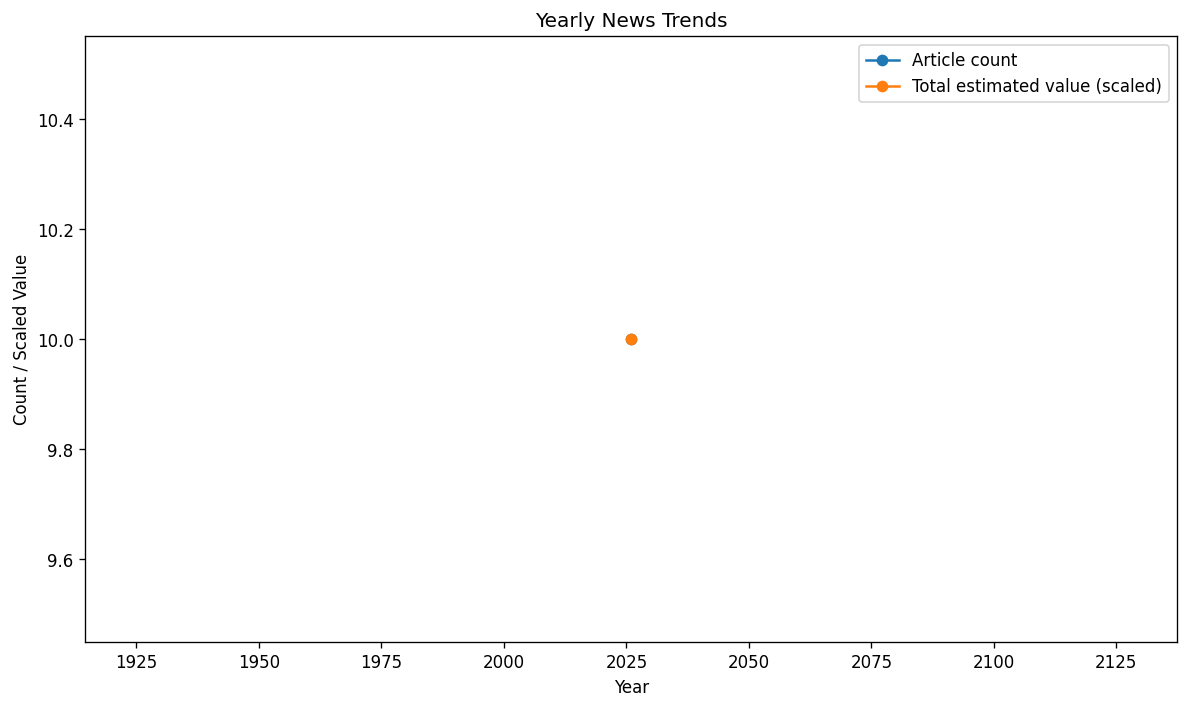

In [7]:
category_df = category_summary(combined_df)
document_df = document_type_summary(combined_df)
yearly_df = yearly_trends(combined_df)
top_articles_df = top_n_per_group(combined_df, n=3)
transformed_df = add_group_average_columns(combined_df)
filtered_large_categories_df = filter_large_categories(combined_df, min_count=5)

yearly_chart_path = save_yearly_trends_chart(yearly_df, str(LAB10_DIR / "yearly_trends.png"))
save_aggregation_outputs(category_df, yearly_df, top_articles_df, document_df, str(LAB10_DIR))

transformed_df.to_csv(LAB10_DIR / "combined_with_group_averages.csv", index=False)
filtered_large_categories_df.to_csv(LAB10_DIR / "large_categories_only.csv", index=False)

print("Category summary:", category_df.shape)
print("Document summary:", document_df.shape)
print("Yearly trends:", yearly_df.shape)
print("Top articles:", top_articles_df.shape)
print("Filtered large categories:", filtered_large_categories_df.shape)
print("Transform columns exist:", "category_avg_rating_score" in transformed_df.columns)

display(category_df.head(10))
display(document_df.head(10))
display(yearly_df)
display(top_articles_df.head(20))

if Path(yearly_chart_path).exists():
    display(Image(filename=yearly_chart_path))

## 6. Time Series Analysis


Valid dates: 10
Monthly rolling: (1, 8)
Yearly time series: (1, 4)
Quarterly time series: (1, 4)


,record_id,analysis_date,analysis_year,analysis_month,analysis_weekday_name,analysis_quarter
201,57,2026-03-23,2026,3,Monday,1
205,60,2026-03-24,2026,3,Tuesday,1
208,56,2026-03-22,2026,3,Sunday,1
209,53,2026-03-21,2026,3,Saturday,1
210,58,2026-03-23,2026,3,Monday,1


,analysis_date,article_count,total_estimated_value,avg_estimated_value,median_estimated_value,rolling_3_month_avg,rolling_6_month_avg,rolling_12_month_avg
0,2026-03-31,10,10315.62,1031.562,1041.34,10315.62,10315.62,10315.62


,analysis_date,article_count,total_estimated_value,avg_estimated_value
0,2026-12-31,10,10315.62,1031.562


,analysis_date,article_count,total_estimated_value,avg_estimated_value
0,2026-03-31,10,10315.62,1031.562


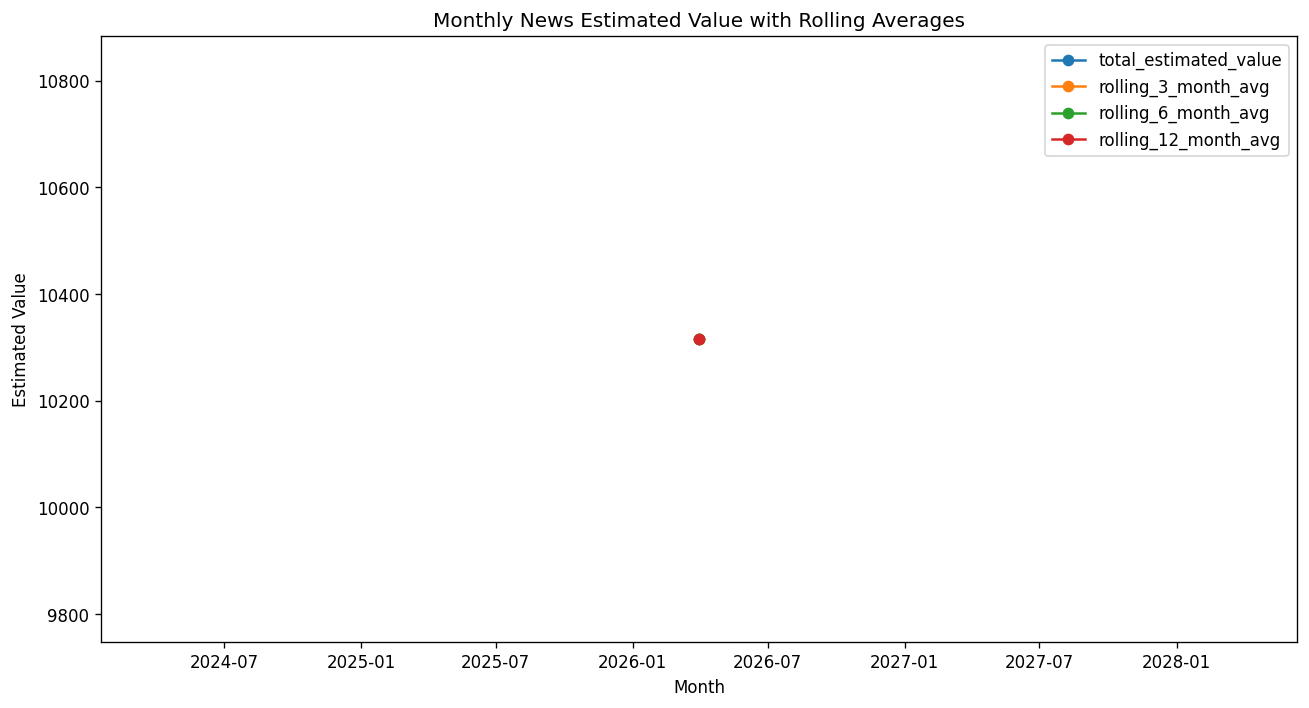

In [8]:
time_series_df = parse_news_dates(combined_df)
time_series_df = add_date_components(time_series_df)

monthly_df = build_monthly_time_series(time_series_df)
yearly_time_series_df = resample_yearly(time_series_df)
quarterly_df = resample_quarterly(time_series_df)
monthly_rolling_df = add_rolling_averages(monthly_df)

rolling_chart_path = save_time_series_chart(monthly_rolling_df, str(LAB10_DIR / "rolling_estimated_value.png"))
save_time_series_outputs(monthly_rolling_df, yearly_time_series_df, quarterly_df, str(LAB10_DIR))

print("Valid dates:", int(time_series_df["analysis_date"].notna().sum()))
print("Monthly rolling:", monthly_rolling_df.shape)
print("Yearly time series:", yearly_time_series_df.shape)
print("Quarterly time series:", quarterly_df.shape)

display(time_series_df[["record_id", "analysis_date", "analysis_year", "analysis_month", "analysis_weekday_name", "analysis_quarter"]].dropna(subset=["analysis_date"]).head())
display(monthly_rolling_df)
display(yearly_time_series_df)
display(quarterly_df)

if Path(rolling_chart_path).exists():
    display(Image(filename=rolling_chart_path))

## 7. MongoDB Aggregation Pipelines

In [9]:
mongo_category_df = run_category_aggregation()
mongo_document_df = run_document_type_aggregation()
mongo_source_df = run_source_aggregation()

save_mongo_aggregation_outputs(mongo_category_df, mongo_document_df, mongo_source_df, str(LAB10_DIR))

print("Mongo category:", mongo_category_df.shape)
print("Mongo document:", mongo_document_df.shape)
print("Mongo source:", mongo_source_df.shape)

display(mongo_category_df.head(10))
display(mongo_document_df.head(10))
display(mongo_source_df.head(10))

Mongo category: (14, 6)
Mongo document: (13, 3)
Mongo source: (22, 2)


,record_count,titles_available,text_records_available,sample_source,category,unique_document_type_count
0,500,0,0,https://www.scrapethissite.com/pages/forms/?pa...,scraped_html_paginated,1
1,435,0,0,https://www.scrapethissite.com/pages/ajax-java...,scraped_json_api,1
2,125,0,0,https://www.scrapethissite.com/pages/forms/,scraped_html,1
3,104,0,0,news_page_1.json,unknown,1
4,70,0,0,data/raw/excel/news_data.xlsx,excel,1
5,56,0,0,data/raw/word/news_normal.docx,word_run,1
6,14,0,0,data/raw/pdf/news_two_column.pdf,pdf_two_column,1
7,14,0,0,data/raw/pdf/news_normal.pdf,pdf,1
8,10,0,0,data/raw/scanned/test_scan.pdf,ocr_pdf,1
9,7,0,0,data/raw/excel/news_data.xlsx,excel_summary,1


,record_count,titles_available,document_type
0,500,0,scraped_html_paginated
1,435,0,scraped_json_api
2,125,0,scraped_html
3,70,0,excel
4,56,0,word_run
5,14,0,pdf_two_column
6,14,0,pdf
7,10,0,ocr_pdf
8,7,0,word
9,7,0,excel_summary


,record_count,source_name
0,125,https://www.scrapethissite.com/pages/forms/?pa...
1,125,https://www.scrapethissite.com/pages/forms/?pa...
2,125,https://www.scrapethissite.com/pages/forms/?pa...
3,125,https://www.scrapethissite.com/pages/forms/
4,125,https://www.scrapethissite.com/pages/forms/?pa...
5,80,https://www.scrapethissite.com/pages/ajax-java...
6,80,https://www.scrapethissite.com/pages/ajax-java...
7,77,data/raw/excel/news_data.xlsx
8,75,https://www.scrapethissite.com/pages/ajax-java...
9,75,https://www.scrapethissite.com/pages/ajax-java...


## 8. Analytical Questions and Charts

In [10]:
insights_df = generate_insight_questions(combined_df)
insight_paths = save_insight_outputs(combined_df, str(LAB10_DIR))

print("Insights shape:", insights_df.shape)
display(insights_df)

for name, path in insight_paths.items():
    print(f"{name}: {path}")

Insights shape: (6, 5)


,question,answer,main_metric,metric_value,supporting_count
0,Which news category has the highest total esti...,The highest total estimated value belongs to '...,total_estimated_value,4536932.4,18
1,Which category has the highest average rating ...,The category with the highest average rating s...,avg_rating_score,10.0,9
2,Which document type appears most often in the ...,The most frequent document type is 'scraped_ht...,article_count,500.0,500
3,Which individual record has the highest estima...,The record with the highest estimated value is...,estimated_value,483310.0,1
4,Which year has the most dated news records?,"The year with the most dated records is 2026, ...",article_count_by_year,10.0,10
5,How many top category-level records were ident...,The top-N category analysis identified 19 lead...,top_records_per_category,19.0,19


analytical_questions_report: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10\analytical_questions_report.csv
insight_category_summary: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10\insight_category_summary.csv
insight_document_type_summary: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10\insight_document_type_summary.csv
insight_yearly_summary: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10\insight_yearly_summary.csv
top_categories_chart: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10\top_categories_estimated_value.png
document_type_chart: c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\data\processed\analytics\lab10\document_type_counts.png
rating_value_scatter: c:\User

top_categories_estimated_value.png exists: True


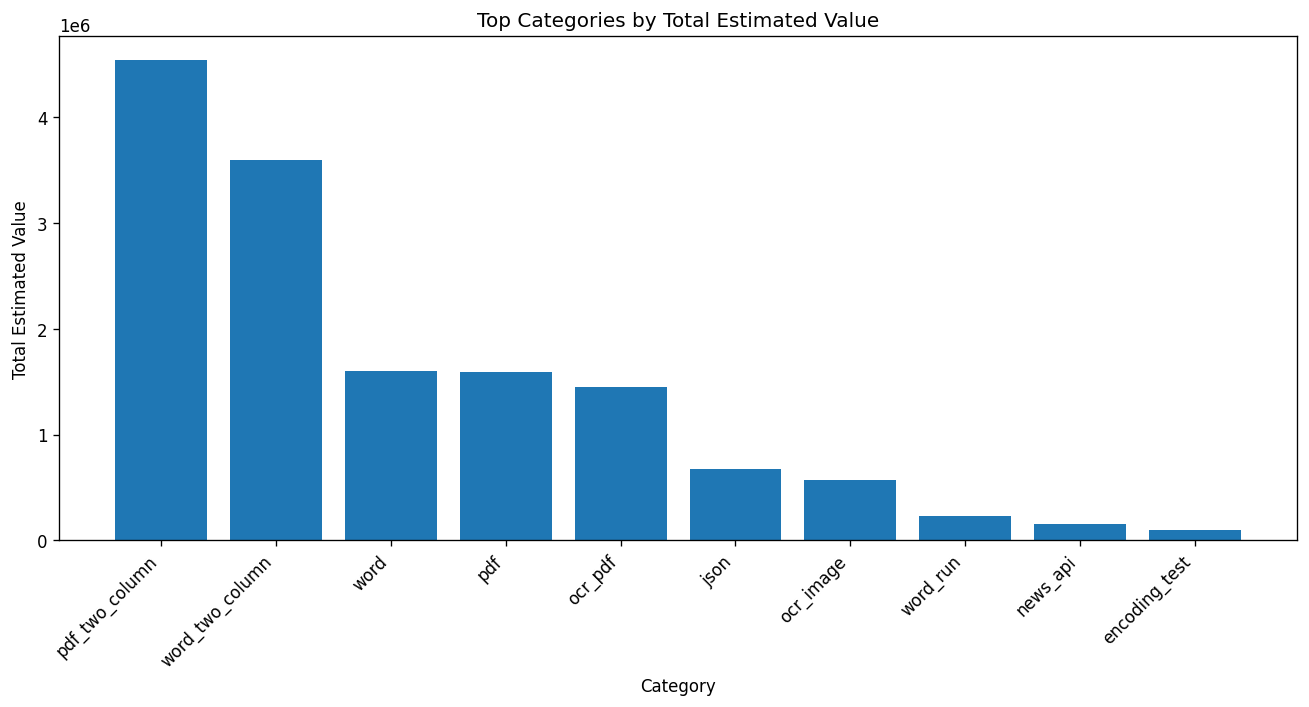

document_type_counts.png exists: True


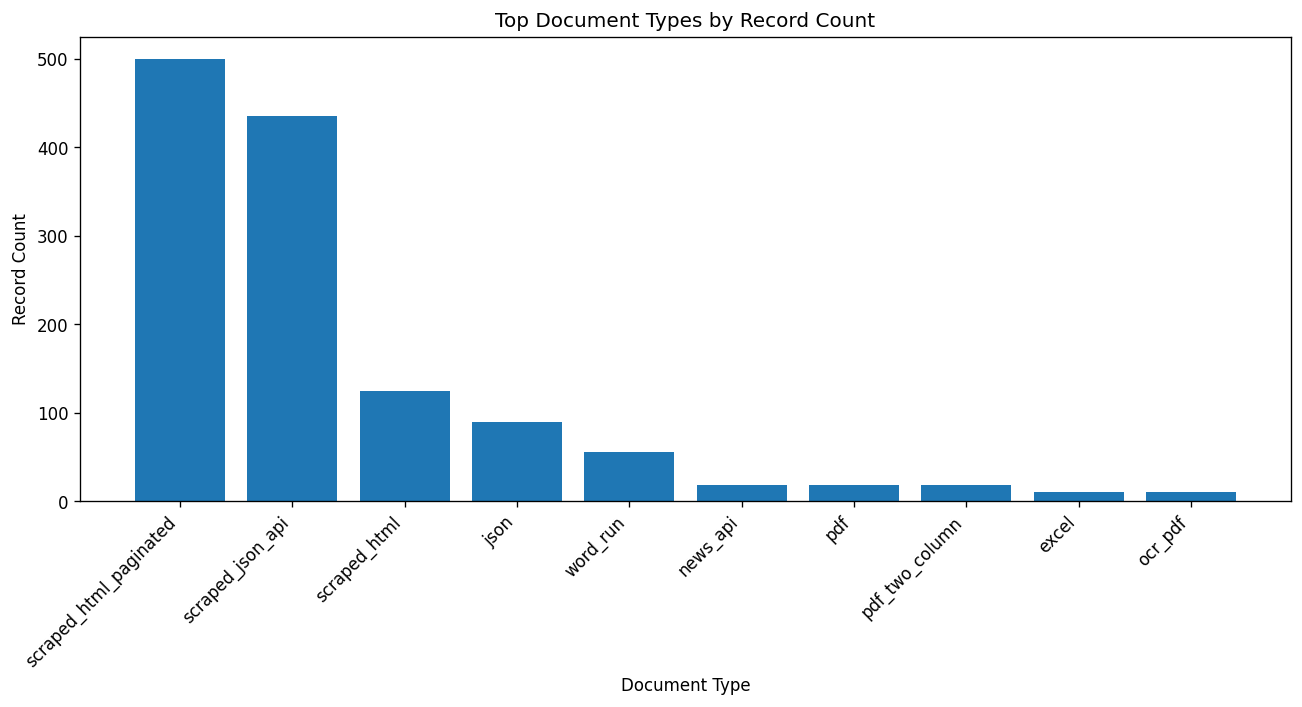

rating_vs_estimated_value.png exists: True


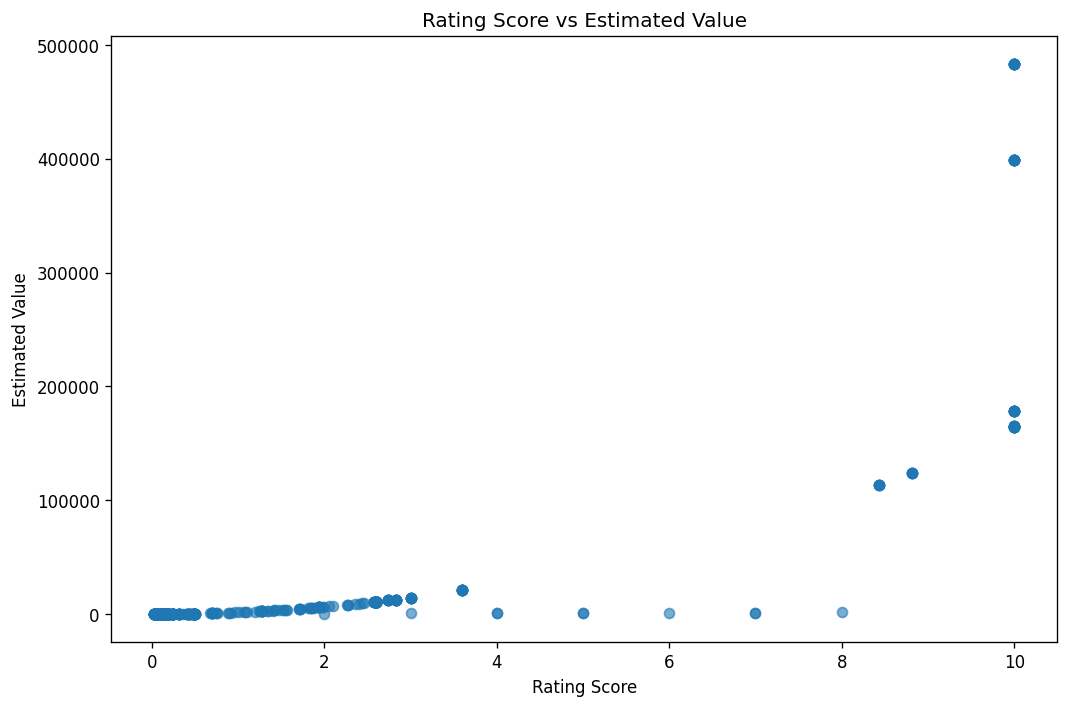

top_articles_estimated_value.png exists: True


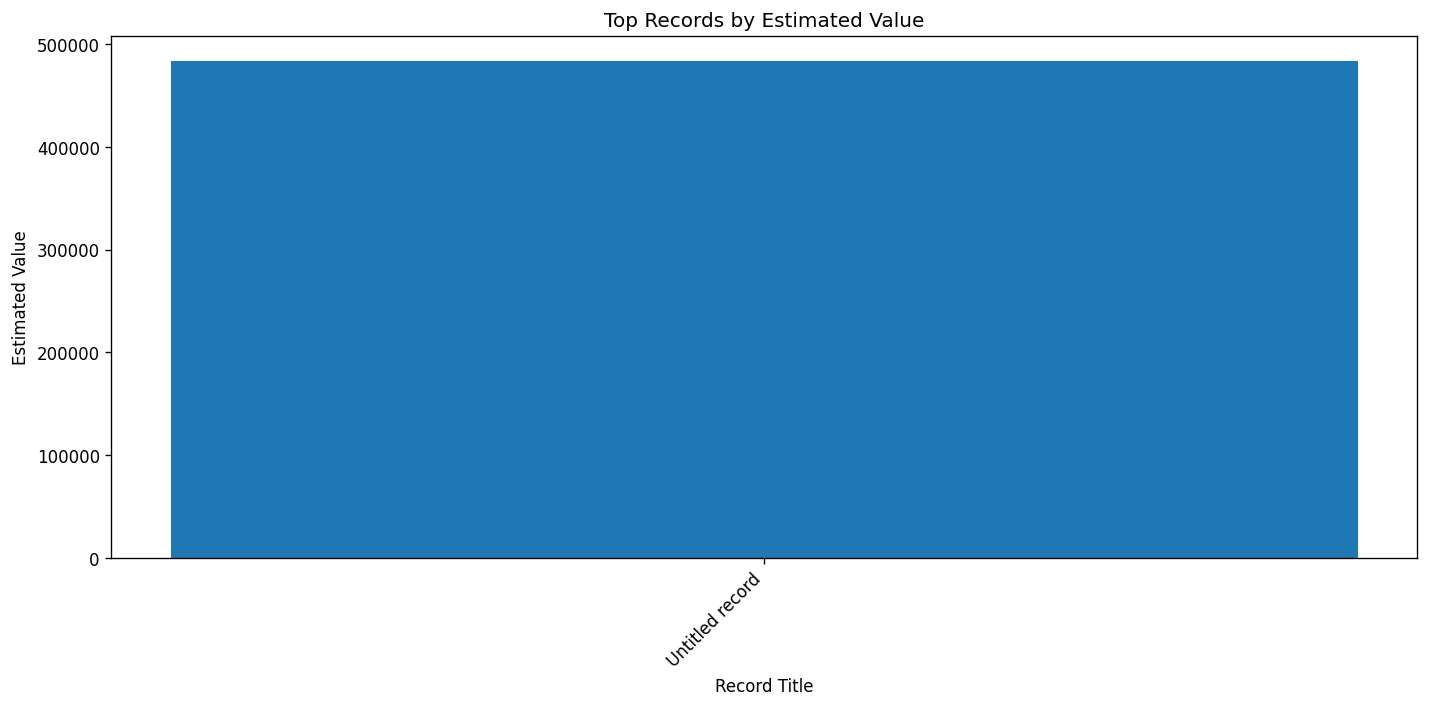

In [11]:
for chart_name in [
    "top_categories_estimated_value.png",
    "document_type_counts.png",
    "rating_vs_estimated_value.png",
    "top_articles_estimated_value.png",
]:
    chart_path = LAB10_DIR / chart_name
    print(chart_name, "exists:", chart_path.exists())
    if chart_path.exists():
        display(Image(filename=str(chart_path)))

## 9. Pipeline Integration

In [12]:
pipeline_result = run_lab10_analysis_stage()
pipeline_result_df = pd.DataFrame([
    {"output": key, "shape": str(value)}
    for key, value in pipeline_result.items()
])
display(pipeline_result_df)

c:\Users\38760\Desktop\Unstructured_Data\News_Media_Monitoring_Pipeline_UD\src\analytics\db_connector.py:419: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connection, params=params)


  inner  join ->  1318 rows
  left   join ->  1318 rows
  right  join ->  1318 rows
  outer  join ->  1318 rows


,output,shape
0,mysql_metrics_shape,"(1318, 13)"
1,combined_shape,"(1318, 26)"
2,join_counts_shape,"(4, 2)"
3,long_metrics_shape,"(6590, 6)"
4,wide_metrics_shape,"(10, 8)"
5,pivot_shape,"(2, 6)"
6,crosstab_shape,"(2, 3)"
7,category_summary_shape,"(19, 13)"
8,document_summary_shape,"(15, 8)"
9,yearly_summary_shape,"(1, 8)"


## 10. Final Output Verification

In [13]:
expected_outputs = [
    "mysql_news_article_metrics.csv",
    "combined_news_metrics.csv",
    "join_type_row_counts.csv",
    "join_type_row_counts.png",
    "news_metrics_long.csv",
    "news_metrics_wide_reconstructed.csv",
    "pivot_category_year.csv",
    "pivot_document_category.csv",
    "language_decade_crosstab.csv",
    "category_analysis.csv",
    "genre_analysis.csv",
    "document_type_analysis.csv",
    "yearly_trends.csv",
    "top_articles_per_category.csv",
    "combined_with_group_averages.csv",
    "large_categories_only.csv",
    "yearly_trends.png",
    "monthly_time_series.csv",
    "yearly_time_series.csv",
    "quarterly_time_series.csv",
    "rolling_estimated_value.png",
    "mongo_category_aggregation.csv",
    "mongo_document_type_aggregation.csv",
    "mongo_source_aggregation.csv",
    "analytical_questions_report.csv",
    "insight_category_summary.csv",
    "insight_document_type_summary.csv",
    "insight_yearly_summary.csv",
    "top_categories_estimated_value.png",
    "document_type_counts.png",
    "rating_vs_estimated_value.png",
    "top_articles_estimated_value.png",
]

verification_df = pd.DataFrame([
    {"file": file_name, "exists": (LAB10_DIR / file_name).exists(), "path": str(LAB10_DIR / file_name)}
    for file_name in expected_outputs
])

display(verification_df)
print("Existing outputs:", int(verification_df["exists"].sum()), "/", len(verification_df))

,file,exists,path
0,mysql_news_article_metrics.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
1,combined_news_metrics.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
2,join_type_row_counts.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
3,join_type_row_counts.png,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
4,news_metrics_long.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
5,news_metrics_wide_reconstructed.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
6,pivot_category_year.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
7,pivot_document_category.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
8,language_decade_crosstab.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...
9,category_analysis.csv,True,c:\Users\38760\Desktop\Unstructured_Data\News_...


Existing outputs: 32 / 32
